In [1]:
import os
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import r2_score

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [2]:
STATIONS = {
    "2590100": {"name": "SENOSHITA",    "river": "CHIKUGO GAWA",  "area": 2315.0},
    "2590101": {"name": "ARASE",        "river": "CHIKUGO GAWA",  "area": 1443.0},
    "2590200": {"name": "HINODE-BASHI", "river": "ONGA GAWA",     "area":  695.0},
    "2590210": {"name": "MUTABE",       "river": "MATSUURA GAWA", "area":  275.0},
    "2590220": {"name": "TAMANA",       "river": "KIKUCHI GAWA",  "area":  906.0},
    "2590230": {"name": "ONOBUCHI",     "river": "SENDAI GAWA",   "area": 1348.0},
    "2590300": {"name": "YOKOISHI",     "river": "KUMA GAWA",     "area": 1856.0},
    "2590301": {"name": "HITOYOSHI",    "river": "KUMA GAWA",     "area": 1137.0},
    "2590400": {"name": "KASHIWADA",    "river": "OYODO GAWA",    "area": 2126.0},
    "2590401": {"name": "HIWATASHI",    "river": "OYODO GAWA",    "area":  860.6},
}

with open("data/processed/config.json") as f:
    config = json.load(f)

STATION_ORDER = config["station_order"]
SCALE_COLS    = config["scale_cols"]
HORIZON       = config["horizon"]
N             = len(STATION_ORDER)

with open("data/processed/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)

# Predictions in scaled log space — shape (674, 7, 10)
pred_stgnn       = np.load("data/processed/pred_stgnn.npy")
pred_nograph     = np.load("data/processed/pred_nograph.npy")
pred_persistence = np.load("data/processed/pred_persistence.npy")
pred_climatology = np.load("data/processed/pred_climatology.npy")
y_true           = np.load("data/processed/y_true_test.npy")

print(f"Predictions shape : {pred_stgnn.shape}  (samples, horizon, N)")
print(f"y_true shape      : {y_true.shape}")

Predictions shape : (674, 7, 10)  (samples, horizon, N)
y_true shape      : (674, 7, 10)


In [3]:
def invert_to_m3s(pred_scaled, scalers, station_order, scale_cols):
    """
    Invert MinMaxScaler then exp(x)-1 to recover m³/s.

    pred_scaled : (samples, horizon, N)  — scaled log(1+Q)
    Returns     : (samples, horizon, N)  — discharge in m³/s
    """
    samples, horizon, N = pred_scaled.shape
    pred_m3s = np.zeros_like(pred_scaled)

    for i, sid in enumerate(station_order):
        scaler  = scalers[sid]
        n_cols  = len(scale_cols)
        discharge_col_idx = scale_cols.index("discharge")

        # Build dummy array: (samples*horizon, n_scale_cols)
        # Fill only the discharge column, others set to 0
        dummy = np.zeros((samples * horizon, n_cols))
        dummy[:, discharge_col_idx] = pred_scaled[:, :, i].flatten()

        # Inverse transform
        inv = scaler.inverse_transform(dummy)
        log_vals = inv[:, discharge_col_idx].reshape(samples, horizon)

        # Invert log transform
        pred_m3s[:, :, i] = np.expm1(log_vals)

    return pred_m3s


y_true_m3s       = invert_to_m3s(y_true,           scalers, STATION_ORDER, SCALE_COLS)
pred_stgnn_m3s   = invert_to_m3s(pred_stgnn,       scalers, STATION_ORDER, SCALE_COLS)
pred_nograph_m3s = invert_to_m3s(pred_nograph,      scalers, STATION_ORDER, SCALE_COLS)
pred_persist_m3s = invert_to_m3s(pred_persistence,  scalers, STATION_ORDER, SCALE_COLS)
pred_clim_m3s    = invert_to_m3s(pred_climatology,  scalers, STATION_ORDER, SCALE_COLS)

print("Inversion complete. Sample m³/s ranges (y_true):")
for i, sid in enumerate(STATION_ORDER):
    vals = y_true_m3s[:, :, i].flatten()
    print(f"  {STATIONS[sid]['name']:15s}  "
          f"min={vals.min():.1f}  max={vals.max():.1f}  "
          f"mean={vals.mean():.1f} m³/s")

Inversion complete. Sample m³/s ranges (y_true):
  SENOSHITA        min=26.5  max=1588.0  mean=105.2 m³/s
  ARASE            min=25.4  max=1432.0  mean=74.1 m³/s
  HINODE-BASHI     min=3.4  max=1057.0  mean=27.2 m³/s
  MUTABE           min=2.1  max=290.6  mean=12.0 m³/s
  TAMANA           min=0.9  max=504.3  mean=31.7 m³/s
  ONOBUCHI         min=20.3  max=1505.0  mean=81.2 m³/s
  YOKOISHI         min=15.9  max=2020.5  mean=112.7 m³/s
  HITOYOSHI        min=17.0  max=1340.4  mean=76.0 m³/s
  KASHIWADA        min=34.5  max=3798.4  mean=149.0 m³/s
  HIWATASHI        min=17.1  max=1317.4  mean=53.2 m³/s


In [4]:
def compute_metrics(pred, target):
    """
    Compute MAE, RMSE, R² over all samples and horizon steps.
    pred, target: (samples, horizon, N)
    Returns DataFrame (N rows, 3 metric columns)
    """
    rows = []
    for i, sid in enumerate(STATION_ORDER):
        p = pred[:, :, i].flatten()
        t = target[:, :, i].flatten()
        mae  = float(np.mean(np.abs(p - t)))
        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        r2   = float(r2_score(t, p))
        rows.append({
            "station": STATIONS[sid]["name"],
            "river":   STATIONS[sid]["river"],
            "MAE":     mae,
            "RMSE":    rmse,
            "R2":      r2,
        })
    return pd.DataFrame(rows).set_index("station")


metrics = {
    "STGNN":       compute_metrics(pred_stgnn_m3s,   y_true_m3s),
    "No-Graph":    compute_metrics(pred_nograph_m3s,  y_true_m3s),
    "Persistence": compute_metrics(pred_persist_m3s,  y_true_m3s),
    "Climatology": compute_metrics(pred_clim_m3s,     y_true_m3s),
}

print("Metrics computed in m³/s for all 4 models.")

Metrics computed in m³/s for all 4 models.


In [5]:
pd.options.display.float_format = "{:.2f}".format

rows = []
for model_name, df in metrics.items():
    rows.append({
        "Model":       model_name,
        "MAE (m³/s)":  df["MAE"].mean(),
        "RMSE (m³/s)": df["RMSE"].mean(),
        "R²":          df["R2"].mean(),
    })

summary = pd.DataFrame(rows).set_index("Model")
print("=== Aggregated Test Metrics (mean across all stations) ===\n")
print(summary.to_string())

=== Aggregated Test Metrics (mean across all stations) ===

             MAE (m³/s)  RMSE (m³/s)    R²
Model                                     
STGNN             31.61       101.78  0.16
No-Graph          32.03       101.12  0.17
Persistence       42.15       125.88 -0.31
Climatology       42.15       110.92  0.01


In [6]:
print("=== Per-Station Metrics — STGNN vs No-Graph ===\n")

comparison = pd.DataFrame({
    "STGNN MAE":    metrics["STGNN"]["MAE"],
    "NoGraph MAE":  metrics["No-Graph"]["MAE"],
    "STGNN RMSE":   metrics["STGNN"]["RMSE"],
    "NoGraph RMSE": metrics["No-Graph"]["RMSE"],
    "STGNN R²":     metrics["STGNN"]["R2"],
    "NoGraph R²":   metrics["No-Graph"]["R2"],
})
print(comparison.to_string())

=== Per-Station Metrics — STGNN vs No-Graph ===

              STGNN MAE  NoGraph MAE  STGNN RMSE  NoGraph RMSE  STGNN R²  NoGraph R²
station                                                                             
SENOSHITA         44.42        45.84      129.17        127.14      0.24        0.27
ARASE             30.76        30.22      101.05        101.33      0.21        0.21
HINODE-BASHI      14.30        14.44       53.41         53.26      0.13        0.13
MUTABE             7.18         7.29       20.79         20.74      0.09        0.09
TAMANA            16.37        16.25       46.82         46.57      0.14        0.15
ONOBUCHI          34.37        34.94      116.80        116.45      0.16        0.17
YOKOISHI          49.26        49.78      158.14        156.66      0.17        0.18
HITOYOSHI         32.75        32.78       98.82         98.70      0.21        0.22
KASHIWADA         65.68        67.99      224.77        222.29      0.13        0.15
HIWATASHI       

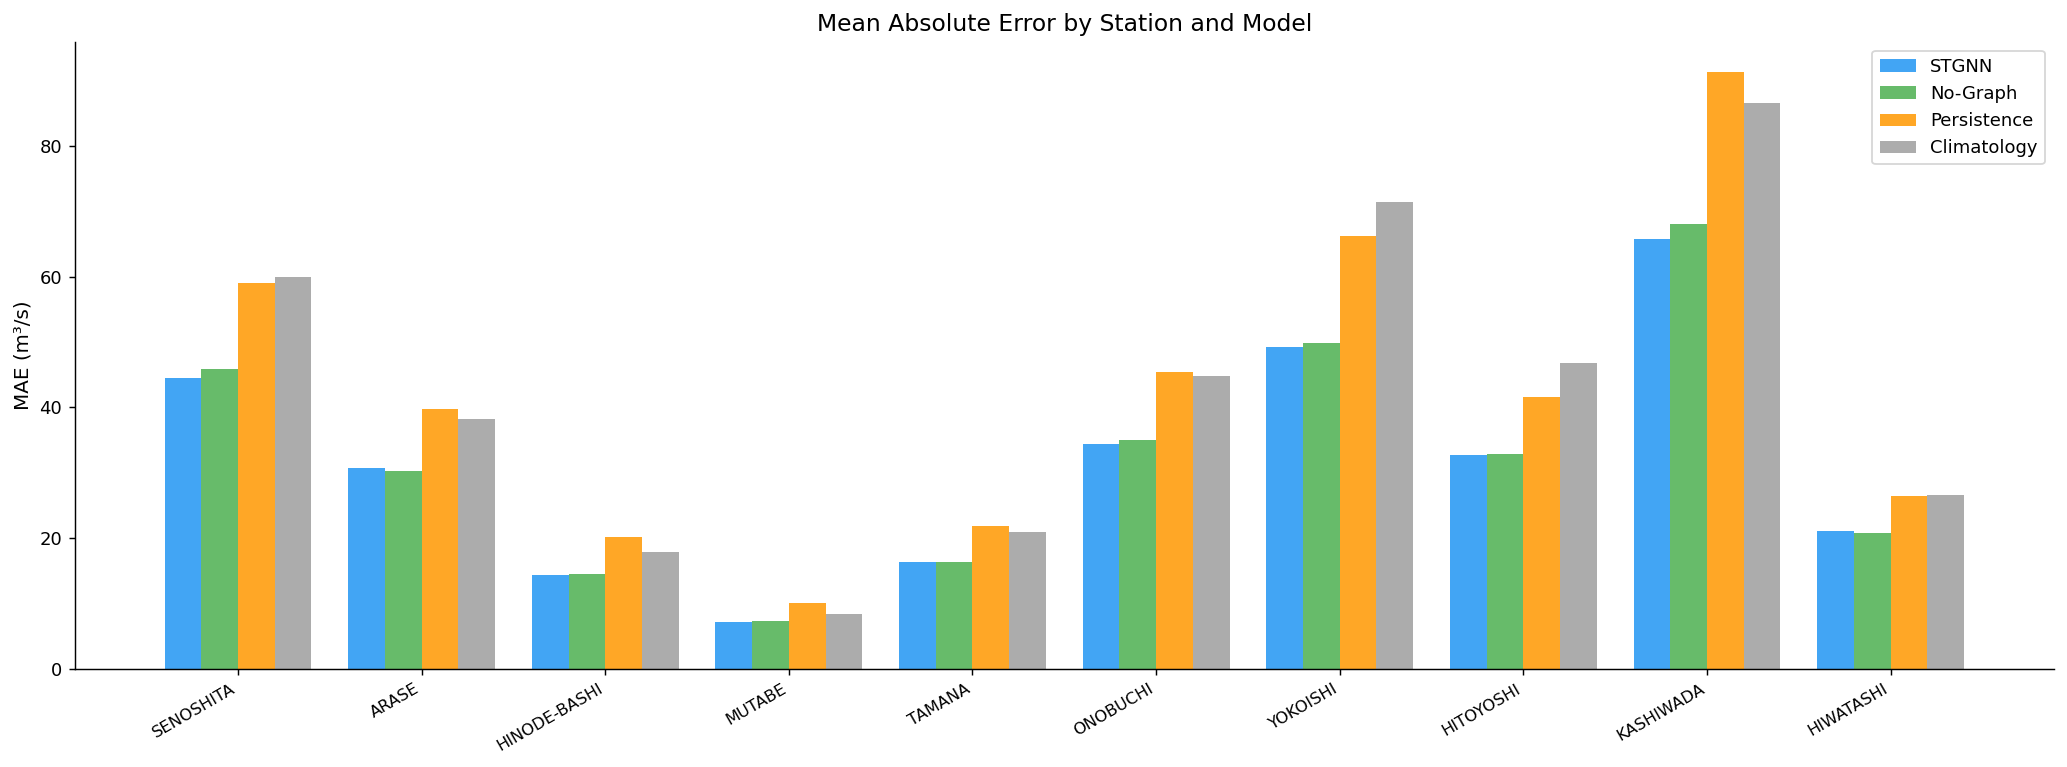

In [7]:
station_names = [STATIONS[s]["name"] for s in STATION_ORDER]
colors = {"STGNN": "#2196F3", "No-Graph": "#4CAF50",
          "Persistence": "#FF9800", "Climatology": "#9E9E9E"}

x = np.arange(N)
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(16, 6))
for (model_name, df), offset in zip(metrics.items(), offsets):
    ax.bar(x + offset * width, df["MAE"], width,
           label=model_name, color=colors[model_name], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(station_names, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("MAE (m³/s)")
ax.set_title("Mean Absolute Error by Station and Model")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

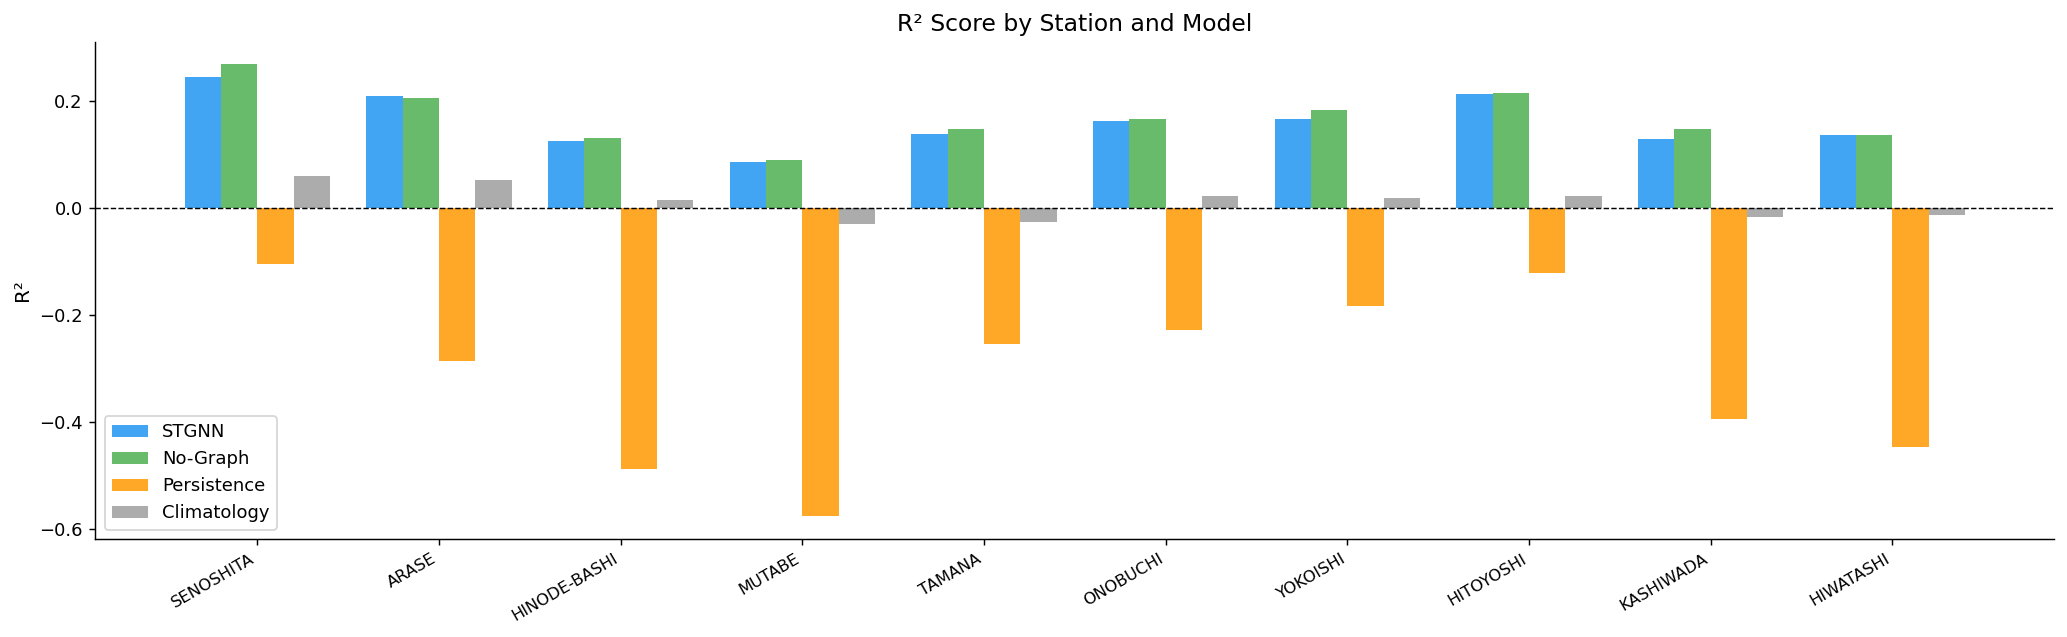

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
for (model_name, df), offset in zip(metrics.items(), offsets):
    ax.bar(x + offset * width, df["R2"], width,
           label=model_name, color=colors[model_name], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(station_names, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("R²")
ax.set_title("R² Score by Station and Model")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

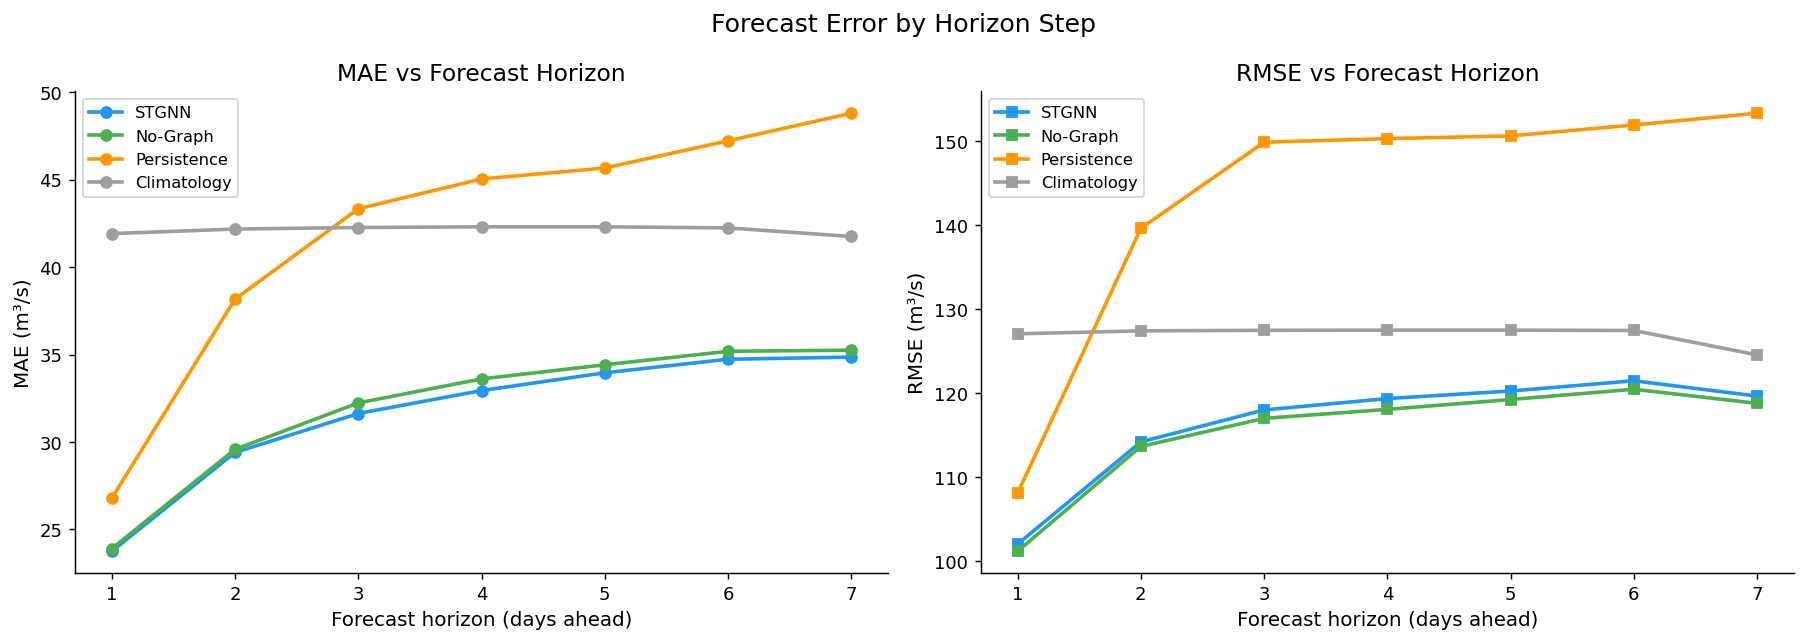

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (pred_nn, pred_ng, label_y) in zip(axes, [
    (pred_stgnn_m3s,   pred_nograph_m3s,  "MAE (m³/s)"),
    (pred_stgnn_m3s,   pred_nograph_m3s,  "RMSE (m³/s)"),
]):
    pass

# MAE by horizon
ax = axes[0]
for model_name, pred in [
    ("STGNN",       pred_stgnn_m3s),
    ("No-Graph",    pred_nograph_m3s),
    ("Persistence", pred_persist_m3s),
    ("Climatology", pred_clim_m3s),
]:
    mae_h = [np.mean(np.abs(pred[:, h, :] - y_true_m3s[:, h, :]))
             for h in range(HORIZON)]
    ax.plot(range(1, HORIZON + 1), mae_h, marker="o", lw=2,
            label=model_name, color=colors[model_name])
ax.set_xlabel("Forecast horizon (days ahead)")
ax.set_ylabel("MAE (m³/s)")
ax.set_title("MAE vs Forecast Horizon")
ax.legend(fontsize=9)
ax.set_xticks(range(1, HORIZON + 1))

# RMSE by horizon
ax = axes[1]
for model_name, pred in [
    ("STGNN",       pred_stgnn_m3s),
    ("No-Graph",    pred_nograph_m3s),
    ("Persistence", pred_persist_m3s),
    ("Climatology", pred_clim_m3s),
]:
    rmse_h = [np.sqrt(np.mean((pred[:, h, :] - y_true_m3s[:, h, :]) ** 2))
              for h in range(HORIZON)]
    ax.plot(range(1, HORIZON + 1), rmse_h, marker="s", lw=2,
            label=model_name, color=colors[model_name])
ax.set_xlabel("Forecast horizon (days ahead)")
ax.set_ylabel("RMSE (m³/s)")
ax.set_title("RMSE vs Forecast Horizon")
ax.legend(fontsize=9)
ax.set_xticks(range(1, HORIZON + 1))

plt.suptitle("Forecast Error by Horizon Step", fontsize=14)
plt.tight_layout()
plt.show()

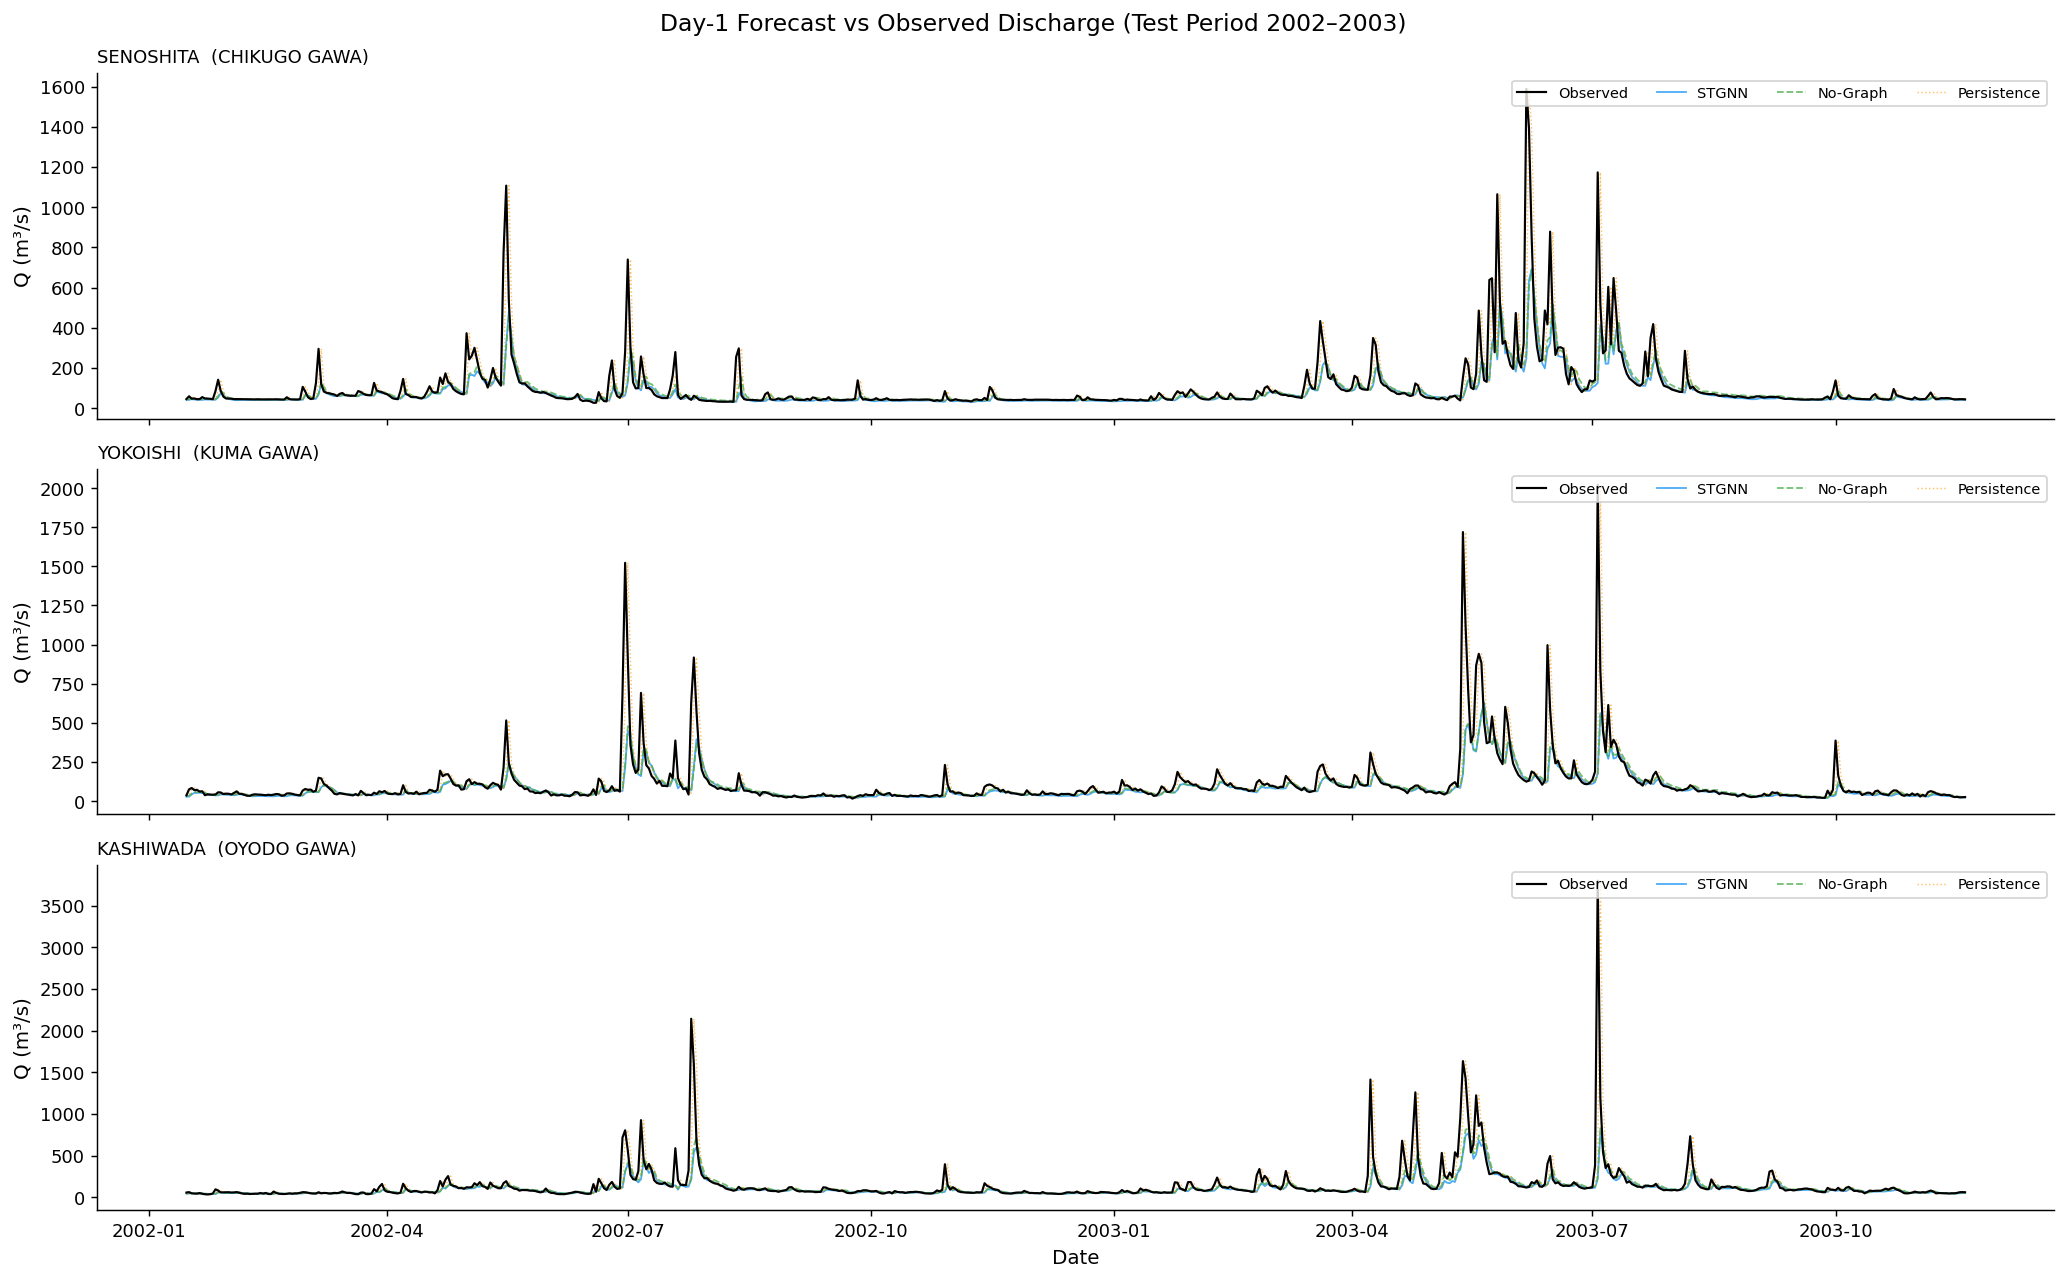

In [10]:
import datetime
start_te = datetime.date(2002, 1, 15)

plot_stations = ["2590100", "2590300", "2590400"]  # Senoshita, Yokoishi, Kashiwada
fig, axes = plt.subplots(len(plot_stations), 1, figsize=(16, 10), sharex=True)

# Use day-1 forecast only for a clean time series
for ax, sid in zip(axes, plot_stations):
    i = STATION_ORDER.index(sid)
    dates = [start_te + datetime.timedelta(days=d)
             for d in range(len(y_true_m3s))]

    ax.plot(dates, y_true_m3s[:, 0, i],
            color="black", lw=1.2, label="Observed", zorder=5)
    ax.plot(dates, pred_stgnn_m3s[:, 0, i],
            color="#2196F3", lw=1, alpha=0.8, label="STGNN")
    ax.plot(dates, pred_nograph_m3s[:, 0, i],
            color="#4CAF50", lw=1, alpha=0.8, label="No-Graph",
            linestyle="--")
    ax.plot(dates, pred_persist_m3s[:, 0, i],
            color="#FF9800", lw=0.8, alpha=0.6, label="Persistence",
            linestyle=":")

    ax.set_ylabel("Q (m³/s)")
    ax.set_title(f"{STATIONS[sid]['name']}  ({STATIONS[sid]['river']})",
                 loc="left", fontsize=10)
    ax.legend(fontsize=8, ncol=4, loc="upper right")

axes[-1].set_xlabel("Date")
fig.suptitle("Day-1 Forecast vs Observed Discharge (Test Period 2002–2003)",
             fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"\n{'Model':15s}  {'MAE':>10s}  {'RMSE':>10s}  {'R²':>8s}")
print("-" * 50)
for model_name, df in metrics.items():
    print(f"{model_name:15s}  "
          f"{df['MAE'].mean():10.2f}  "
          f"{df['RMSE'].mean():10.2f}  "
          f"{df['R2'].mean():8.3f}")
print("-" * 50)
print("\nUnits: MAE and RMSE in m³/s | R² dimensionless")
print("Evaluation period: 2002-01-01 → 2003-12-31")
print("N test windows: 674  |  Horizon: 7 days  |  N stations: 10")

FINAL RESULTS SUMMARY

Model                   MAE        RMSE        R²
--------------------------------------------------
STGNN                 31.61      101.78     0.161
No-Graph              32.03      101.12     0.169
Persistence           42.15      125.88    -0.308
Climatology           42.15      110.92     0.011
--------------------------------------------------

Units: MAE and RMSE in m³/s | R² dimensionless
Evaluation period: 2002-01-01 → 2003-12-31
N test windows: 674  |  Horizon: 7 days  |  N stations: 10
